In [1]:
!pip -q install kagglehub
import kagglehub

path = kagglehub.dataset_download("oddrationale/mnist-in-csv")
print(path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
/kaggle/input/mnist-in-csv


In [2]:
import pandas as pd, numpy as np, os

train = pd.read_csv(os.path.join(path, "mnist_train.csv"))
test  = pd.read_csv(os.path.join(path, "mnist_test.csv"))

y_train = train.iloc[:, 0].values
x_train = train.iloc[:, 1:].values.reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_test  = test.iloc[:, 0].values
x_test  = test.iloc[:, 1:].values.reshape(-1, 28, 28, 1).astype("float32") / 255.0
print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [4]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = (x_train[..., None] / 255.0).astype("float32")
x_test  = (x_test[..., None] / 255.0).astype("float32")
print(x_train.shape, x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28, 1) (10000, 28, 28, 1)


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np


In [8]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = (x_train[..., None] / 255.0).astype("float32")
x_test  = (x_test[..., None] / 255.0).astype("float32")

In [9]:
odel = models.Sequential([
    layers.Input((28, 28, 1)),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

In [10]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [11]:
model.fit(x_train, y_train, epochs=8, batch_size=128,
          validation_data=(x_test, y_test))

Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9628 - loss: 0.1226 - val_accuracy: 0.9857 - val_loss: 0.0414
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9692 - loss: 0.0989 - val_accuracy: 0.9898 - val_loss: 0.0324
Epoch 3/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9737 - loss: 0.0837 - val_accuracy: 0.9898 - val_loss: 0.0304
Epoch 4/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9772 - loss: 0.0770 - val_accuracy: 0.9887 - val_loss: 0.0356
Epoch 5/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9787 - loss: 0.0676 - val_accuracy: 0.9911 - val_loss: 0.0250
Epoch 6/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9806 - loss: 0.0627 - val_accuracy: 0.9891 - val_loss: 0.0360
Epoch 7/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9813 - loss: 0.0611 - val_accuracy: 0.9905 - val_loss: 0.0304
Epoch 8/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9827 - loss: 0.0558 - val_accuracy: 0.9929 -

In [12]:
model.save("mnist_model.keras")

In [18]:
import cv2
import matplotlib.pyplot as plt
def find_plate(img, debug=False):
    """کادر پلاک را به صورت (x, y, w, h) برمی‌گرداند."""
    H0, W0 = img.shape[:2]
    s = 800 / W0
    small = cv2.resize(img, None, fx=s, fy=s)
    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    H, W = gray.shape

    rectK = cv2.getStructuringElement(cv2.MORPH_RECT, (31, 9))
    best, best_area = None, 0

    # BLACKHAT: نوشته تیره روی پلاک روشن | TOPHAT: نوشته روشن روی پلاک تیره
    for op in (cv2.MORPH_BLACKHAT, cv2.MORPH_TOPHAT):
        mh = cv2.morphologyEx(gray, op, rectK)
        gx = np.absolute(cv2.Sobel(mh, cv2.CV_32F, 1, 0, ksize=-1))
        gx = (255 * (gx - gx.min()) / (gx.max() - gx.min() + 1e-6)).astype("uint8")
        gx = cv2.morphologyEx(gx, cv2.MORPH_CLOSE, rectK)
        th = cv2.threshold(gx, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
        th = cv2.erode(th, None, iterations=2)
        th = cv2.dilate(th, None, iterations=2)

        if debug:
            plt.figure(figsize=(6, 3)); plt.imshow(th, cmap="gray")
            plt.title("candidates"); plt.axis("off"); plt.show()

        cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            x, y, w, h = cv2.boundingRect(c)
            if h == 0: continue
            if 1.8 < w / h < 7 and w > 0.08 * W and h > 0.03 * H:
                if w * h > best_area:
                    best, best_area = (x, y, w, h), w * h

    if best is None:
        return None
    x, y, w, h = best
    pad = int(0.1 * h)                       # کمی حاشیه
    x, y = max(x - pad, 0), max(y - pad, 0)
    w, h = min(w + 2 * pad, W - x), min(h + 2 * pad, H - y)
    return int(x / s), int(y / s), int(w / s), int(h / s)   # برگرداندن به ابعاد اصلی

In [21]:
def read_digits(plate_img, invert=True, min_rel_h=0.6):
    g = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    g = cv2.resize(g, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    g = cv2.GaussianBlur(g, (5, 5), 0)
    mode = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, th = cv2.threshold(g, 0, 255, mode + cv2.THRESH_OTSU)

    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    H = th.shape[0]
    boxes = [cv2.boundingRect(c) for c in cnts]
    boxes = [b for b in boxes if b[3] < 0.95 * H and b[2] < b[3] * 1.2]
    if not boxes:
        return [], th

    # فقط کانتورهای بلند (ارقام اصلی) را نگه می‌داریم
    max_h = max(b[3] for b in boxes)
    boxes = [b for b in boxes if b[3] >= min_rel_h * max_h]
    boxes.sort(key=lambda b: b[0])             # از چپ به راست

    result = []
    for (x, y, w, h) in boxes:
        d = prepare_digit(th[y:y+h, x:x+w])
        pred = model.predict(d[None, ..., None], verbose=0)[0]
        result.append((x, y, w, h, int(pred.argmax()), float(pred.max())))
    return result, th

Saving images (1).jfif to images (1) (3).jfif
ارقام تشخیص داده شده: 300160
اطمینان هر رقم: [1.0, 1.0, 1.0, 1.0, 0.64, 1.0]


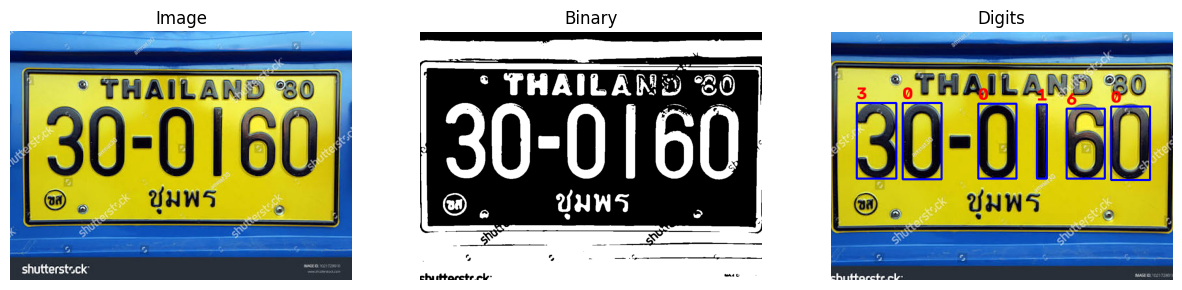

In [23]:
from google.colab import files
up = files.upload()
path = list(up.keys())[0]

img = cv2.imread(path)
H0, W0 = img.shape[:2]

# حذف ۴٪ حاشیه تا قاب پلاک با ارقام یکی نشود
my, mx = int(0.04 * H0), int(0.04 * W0)
plate = img[my:H0-my, mx:W0-mx]

digits, th = read_digits(plate)       # پلاک تیره: invert=False

vis = plate.copy()
for (dx, dy, dw, dh, label, conf) in digits:
    cv2.rectangle(vis, (dx//2, dy//2), ((dx+dw)//2, (dy+dh)//2), (255, 0, 0), 2)
    cv2.putText(vis, f"{label}", (dx//2, max(dy//2-5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

print("ارقام تشخیص داده شده:", "".join(str(d[4]) for d in digits))
print("اطمینان هر رقم:", [round(d[5], 2) for d in digits])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title("Image")
ax[1].imshow(th, cmap="gray");                      ax[1].set_title("Binary")
ax[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); ax[2].set_title("Digits")
for a in ax: a.axis("off")
plt.show()